In [19]:
import accelforge as af
from scheduling.scheduler import *
from af_wrapper import *
import numpy as np


def run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = None,
    total_latency_grid = None,
    actions_grid = None,
    memory_name = None,
    shared_memory_info = None,
):
    schedule, min_latency = best_schedule(
        einsums,
        compute_units,
        shared_memory_info,
        data_dependencies,
        latency_per_component_grid,
        total_latency_grid,
        actions_grid,
        memory_name
    )
    return schedule, min_latency

In [42]:
arch = "arch/eyeriss-shared-mem/full.yaml"
subarch_path = "arch/eyeriss-shared-mem/"
bandwidth = 6.4e9
    # tpu (8 * 614e9)
    # eyeriss 6.4e9

workload = "workload/6mm-sequential/full.yaml"
einsum_to_file = lambda einsum: "workload/6mm-sequential/"+einsum+".yaml"

filename = "mem-intensive-tpu"

In [32]:
data_dependencies = {
    # chain 1
    "Y1": [],
    "Y2": ["Y1"],

    # chain 2
    "Z1": [],
    "Z2": ["Z1"],

    # fan-in (elementwise add)
    "OUT": ["Y2", "Z2"],
}


compute_units = ['slow', 'fast'] # ['1', '2', '3', '4']
    # eyeriss ['slow', 'fast']
einsums = data_dependencies.keys()
memory_name = "MainMemory"
shared_mem_info = {'GlobalBuffer' : [(50, 50), (25, 75), (75, 25)]} # [(50, 25, 15, 10), (25, 25, 25, 25)]}
    # eyeriss [(50, 50), (25, 75), (75, 25)]

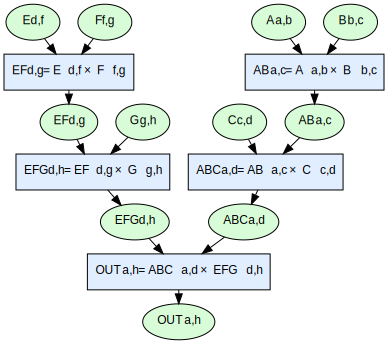

In [43]:
spec = af.Spec.from_yaml(arch, workload)
spec.workload

# AF baseline

In [23]:
m = af_map(arch, workload)

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 5/5 [00:02<00:00,  2.00it/s]
Generating pmapping templates for compute SlowMAC Einsum Z2: 46it [00:00, 68.40it/s]]
Generating pmapping templates for compute SlowMAC Einsum OUT: 46it [00:01, 41.91it/s]
Generating pmapping templates for compute FastMAC Einsum Z2: 46it [00:01, 41.33it/s]]
Generating pmapping templates for compute SlowMAC Einsum Z1: 27it [00:00, 77.37it/s]]
Generating pmapping templates for compute SlowMAC Einsum Y1: 27it [00:00, 76.95it/s]]
Generating pmapping templates for compute FastMAC Einsum OUT: 46it [00:00, 48.68it/s]
Generating pmapping templates for compute FastMAC Einsum Y1: 27it [00:00, 82.47it/s]
Generating pmapping templates for compute FastMAC Einsum Z1: 27it [00:00, 62.48it/s]
Generating pmapping templates for compute SlowMAC Einsum Y2: 46it [00:00, 68.47it/s]
Generating pmapping templates for compute FastMAC Einsum Y2: 46it [00:00, 90.90it/s]
Generating jobs: 100

Einsum Y1 has 54 pmapping jobs:
	0	[Y0 in MainMemory] [A1 in MainMemory] T-c  [Y1 in GlobalBuffer] T-a  T-c  S-reuse_output-a  S-reuse_weight-c  [A1 in SlowInputScratchpad] [Y0 in SlowWeightScratchpad] T-c  [Y1 in SlowOutputScratchpad] T-a  SlowMAC computes Y1
	1	[Y0 in MainMemory] [A1 in MainMemory] T-c  [A1 in GlobalBuffer] [Y1 in GlobalBuffer] T-a  T-c  S-reuse_output-a  S-reuse_weight-c  [A1 in SlowInputScratchpad] [Y0 in SlowWeightScratchpad] T-c  [Y1 in SlowOutputScratchpad] T-a  SlowMAC computes Y1
	2	[Y0 in MainMemory] [A1 in MainMemory] T-c  [Y1 in GlobalBuffer] T-a  T-c  [A1 in GlobalBuffer] S-reuse_output-a  S-reuse_weight-c  [A1 in SlowInputScratchpad] [Y0 in SlowWeightScratchpad] T-c  [Y1 in SlowOutputScratchpad] T-a  SlowMAC computes Y1
	3	[Y0 in MainMemory] [A1 in MainMemory] T-c  [Y1 in GlobalBuffer] T-a  [Y0 in GlobalBuffer] T-c  S-reuse_output-a  S-reuse_weight-c  [A1 in SlowInputScratchpad] [Y0 in SlowWeightScratchpad] T-c  [Y1 in SlowOutputScratchpad] T-a  SlowMAC c

Compressing pmappings: 100%|██████████| 5/5 [00:00<00:00, 81.99it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 31/31 [00:00<00:00, 538.03it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>latency=8.30e-05    Total<SEP>energy=4.82e-06
Final clean join.


Dirty pruning pmappings: 100%|██████████| 31/31 [00:00<00:00, 614.71it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 91 -> 91 (100.00% kept) pmappings


Grouping pmappings: 100%|██████████| 1/1 [00:00<00:00, 127.57it/s]


Dirty joining mapping(s) valid & optimal! Returning...


In [24]:
af_baseline = m[0]
for i in range(len(m)):
    if m[i].latency() < af_baseline.latency():
        af_baseline = m[i]

In [25]:
svg_name = "images/af_baseline-"+filename+".svg"
with open(svg_name, "w") as f:
    f.write(af_baseline.render())

In [26]:
print('AF baseline for', workload, 'on', subarch_path)
print('\tMapping image written to', svg_name)
print('\tLatency:', af_baseline.latency())
mems = sum(n for ((unit, act), n) in af_baseline[0].actions(per_component=True).items() if unit == 'MainMemory')
print('\tMemory operations:', mems)
print('\tAverage bandwidth utilization:', (mems/af_baseline.latency()) / bandwidth)

AF baseline for workload/mem-intensive/full.yaml on arch/eyeriss-shared-mem/
	Mapping image written to images/af_baseline-mem-intensive-tpu.svg
	Latency: 8.295925604098097e-05
	Memory operations: 527360.0
	Average bandwidth utilization: 0.9932586661492637


# Us

In [33]:
from arch.arch_utils import *
arch_pairings = generate_architecture_pairings(compute_units, shared_mem_info)

In [34]:
arch_pairings

[('slow', ('GlobalBuffer', 25)),
 ('slow', ('GlobalBuffer', 50)),
 ('slow', ('GlobalBuffer', 75)),
 ('fast', ('GlobalBuffer', 25)),
 ('fast', ('GlobalBuffer', 50)),
 ('fast', ('GlobalBuffer', 75))]

In [35]:
(grid_lats, grid_mems) = af_memoizable_grid_mem(
    einsums, 
    arch_pairings,
    einsum_to_file,
    subarch_path
)

Getting cell 1 of 30 : Y1 ('slow', ('GlobalBuffer', 25))


Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 1/1 [00:00<00:00,  5.89it/s]
Generating jobs:   0%|          | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute SlowMAC Einsum Y1: 0it [00:00, ?it/s]
Generating pmapping templates for compute SlowMAC Einsum Y1: 16it [00:00, 55.23it/s][A
Generating jobs: 100%|██████████| 1/1 [00:00<00:00,  3.11it/s]


Einsum Y1 has 16 pmapping jobs:
	0	[Y1 in MainMemory] [Y0 in MainMemory] [A1 in MainMemory] T-m  T-n  S-reuse_output-n  S-reuse_weight-m  [A1 in SlowInputScratchpad] [Y0 in SlowWeightScratchpad] T-m  [Y1 in SlowOutputScratchpad] T-n  SlowMAC computes Y1
	1	[Y1 in MainMemory] [Y0 in MainMemory] [A1 in MainMemory] T-m  T-n  [A1 in GlobalBuffer] S-reuse_output-n  S-reuse_weight-m  [A1 in SlowInputScratchpad] [Y0 in SlowWeightScratchpad] T-m  [Y1 in SlowOutputScratchpad] T-n  SlowMAC computes Y1
	2	[Y1 in MainMemory] [Y0 in MainMemory] [A1 in MainMemory] T-n  [Y0 in GlobalBuffer] T-m  S-reuse_output-n  S-reuse_weight-m  [A1 in SlowInputScratchpad] [Y0 in SlowWeightScratchpad] T-m  [Y1 in SlowOutputScratchpad] T-n  SlowMAC computes Y1
	3	[Y1 in MainMemory] [Y0 in MainMemory] [A1 in MainMemory] T-m  [Y1 in GlobalBuffer] T-n  S-reuse_output-n  S-reuse_weight-m  [A1 in SlowInputScratchpad] [Y0 in SlowWeightScratchpad] T-m  [Y1 in SlowOutputScratchpad] T-n  SlowMAC computes Y1
	4	[Y1 in MainMem

Compressing pmappings: 100%|██████████| 1/1 [00:00<00:00, 437.27it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


...

Filtering out pmappings worse than the following:
	Total<SEP>latency=7.19e-07    Total<SEP>energy=2.65e-08
Final clean join.


Dirty pruning pmappings: 100%|██████████| 1/1 [00:00<00:00, 949.80it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|██████████| 1/1 [00:00<00:00, 493.74it/s]


Dirty joining mapping(s) valid & optimal! Returning...


In [6]:
# RUN TO GENERATE ACCELFORGE VALUES FOR SHARED MEMORY-AWARE SCHEDULING.
# split into separate cells for eyeriss
# (grid_lats_f, grid_mems_f) = af_memoizable_grid_mem(
#     einsums, 
#     [a for a in arch_pairings if a[0] == 'fast'],
#     einsum_to_file,
#     subarch_path
# )
# (grid_lats_s, grid_mems_s) = af_memoizable_grid_mem(
#     einsums, 
#     [a for a in arch_pairings if a[0] == 'slow'],
#     einsum_to_file,
#     subarch_path
# )
# grid_mems = grid_mems_s | grid_mems_f
# grid_lats = grid_lats_s | grid_lats_f

In [36]:
schedule, latency = run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = grid_lats,
    actions_grid = grid_mems,
    memory_name = memory_name,
    shared_memory_info = shared_mem_info
)

Assignment 0 of 7776
Assignment 1 of 7776
Assignment 2 of 7776
Assignment 3 of 7776
Assignment 4 of 7776
Assignment 5 of 7776
Assignment 6 of 7776
Assignment 7 of 7776
Assignment 8 of 7776
Assignment 9 of 7776
Assignment 10 of 7776
Assignment 11 of 7776
Assignment 12 of 7776
Assignment 13 of 7776
Assignment 14 of 7776
Assignment 15 of 7776
Assignment 16 of 7776
Assignment 17 of 7776
Assignment 18 of 7776
Assignment 19 of 7776
Assignment 20 of 7776
Assignment 21 of 7776
Assignment 22 of 7776
Assignment 23 of 7776
Assignment 24 of 7776
Assignment 25 of 7776
Assignment 26 of 7776
Assignment 27 of 7776
Assignment 28 of 7776
Assignment 29 of 7776
Assignment 30 of 7776
Assignment 31 of 7776
Assignment 32 of 7776
Assignment 33 of 7776
Assignment 34 of 7776
Assignment 35 of 7776
Assignment 36 of 7776
Assignment 37 of 7776
Assignment 38 of 7776
Assignment 39 of 7776
Assignment 40 of 7776
Assignment 41 of 7776
Assignment 42 of 7776
Assignment 43 of 7776
Assignment 44 of 7776
Assignment 45 of 777

In [37]:
print('Heterogenius schedule for', workload, 'on', subarch_path)
print('\tSchedule:\n', schedule)
print('\tLatency:', latency)
mems = sum(
    sum(
        count
        for (action, count) in grid_mems[(node.compute_assignment, node.einsum_name)].items()
        if action[0] == memory_name
    ) 
    for node in schedule.keys()
)
print('\tMemory operations:', mems)
print('\tAverage bandwidth utilization:', (mems/latency) / bandwidth)

Heterogenius schedule for workload/mem-intensive/full.yaml on arch/eyeriss-shared-mem/
	Schedule:
 {(Y1, ('slow', ('GlobalBuffer', 25)), latency=2.080000012938399e-05): 0, (Y2, ('slow', ('GlobalBuffer', 25)), latency=2.080000012938399e-05): np.float64(2.080000012938399e-05), (Z1, ('slow', ('GlobalBuffer', 25)), latency=2.080000012938399e-05): np.float64(4.160000025876798e-05), (Z2, ('slow', ('GlobalBuffer', 25)), latency=2.080000012938399e-05): np.float64(6.240000038815197e-05), (OUT, ('fast', ('GlobalBuffer', 25)), latency=7.19256036063598e-07): np.float64(8.320000051753595e-05)}
	Latency: 8.391925655359955e-05
	Memory operations: 535552.0
	Average bandwidth utilization: 0.9971489671926879
